# *Personal Finance Budget Status Prediction*

The Main Objective of the project is predict a Customer are under budgte or over budget 

Import Required Liabraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors  import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
precision_score,
recall_score,
f1_score

)


# hyperparameter Tuning
from sklearn.model_selection import GridSearchCV


Load the dataset

In [32]:
df = pd.read_excel(r"C:\Users\Bhushan Sawant\Downloads\Personal_Finance_Budget_Prediction_Dataset.xlsx")

Display first 5 rows

In [33]:
df.head()

,Customer_ID,Age,Gender,Marital_Status,Education,Occupation,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Financial_Goal,Credit_Score,Budget_Status
0,CUST000001,61,Male,Married,Bachelor's,Engineer,20000,15900,4600,0,4100,0.00,Retirement,776,Under Budget
1,CUST000002,30,Male,Married,Master's,Engineer,125300,118500,2600,5400,6800,0.04,Retirement,697,Under Budget
2,CUST000003,42,Male,Divorced,High School,IT Professional,65600,55200,8700,0,10400,0.00,Education,789,Under Budget
3,CUST000004,27,Male,Single,Bachelor's,IT Professional,33100,23500,300,9800,9600,0.30,Travel,675,Under Budget
4,CUST000005,18,Female,Single,Master's,Teacher,35000,26000,5200,4400,9000,0.13,Home Purchase,768,Under Budget


In [34]:
df.tail()

,Customer_ID,Age,Gender,Marital_Status,Education,Occupation,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Financial_Goal,Credit_Score,Budget_Status
9995,CUST009996,19,Male,Single,Bachelor's,Engineer,38900,11700,9900,3900,27200,0.10,Retirement,794,Under Budget
9996,CUST009997,51,Male,Divorced,Master's,Accountant,110100,79900,15200,11100,30200,0.10,Investment,696,Under Budget
9997,CUST009998,19,Female,Single,High School,Engineer,25926,15663,5200,4000,10263,0.15,Education,701,Over Budget
9998,CUST009999,54,Female,Married,Master's,Accountant,70500,45300,7200,16300,25200,0.23,Retirement,654,Under Budget
9999,CUST010000,54,Male,Married,Bachelor's,Teacher,40825,33108,1200,17800,7717,0.44,Education,612,Over Budget


Check number of rows  and columns

In [35]:
df.shape

(10000, 15)

Display all column names

In [36]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education',
       'Occupation', 'Monthly_Income', 'Total_Expenses', 'Savings', 'EMI',
       'Budget_Remaining', 'Debt_to_Income_Ratio', 'Financial_Goal',
       'Credit_Score', 'Budget_Status'],
      dtype='object')

In [37]:
df.info

<bound method DataFrame.info of      Customer_ID  Age  Gender Marital_Status    Education       Occupation  \
0     CUST000001   61    Male        Married   Bachelor's         Engineer   
1     CUST000002   30    Male        Married     Master's         Engineer   
2     CUST000003   42    Male       Divorced  High School  IT Professional   
3     CUST000004   27    Male         Single   Bachelor's  IT Professional   
4     CUST000005   18  Female         Single     Master's          Teacher   
...          ...  ...     ...            ...          ...              ...   
9995  CUST009996   19    Male         Single   Bachelor's         Engineer   
9996  CUST009997   51    Male       Divorced     Master's       Accountant   
9997  CUST009998   19  Female         Single  High School         Engineer   
9998  CUST009999   54  Female        Married     Master's       Accountant   
9999  CUST010000   54    Male        Married   Bachelor's          Teacher   

      Monthly_Income  Total_Exp

Statistical Summary

In [38]:
df.describe()

,Age,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Credit_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.474900,62664.249400,45074.797600,7317.560000,11797.510000,17589.451800,0.189472,676.345200
std,13.899953,39269.563549,31998.208441,9325.056639,13890.639574,19140.018416,0.161828,82.947691
min,18.000000,20000.000000,10000.000000,0.000000,0.000000,-31700.000000,0.000000,406.000000
25%,29.000000,31700.000000,21022.250000,1700.000000,0.000000,5300.000000,0.000000,611.000000
50%,41.000000,52600.000000,36217.500000,3600.000000,7700.000000,12510.000000,0.180000,673.000000
75%,54.000000,84500.000000,59400.000000,9300.000000,17700.000000,25627.500000,0.360000,745.000000
max,65.000000,250000.000000,200275.000000,102200.000000,80000.000000,146042.000000,0.450000,900.000000


In [39]:
df.dtypes

Customer_ID              object
Age                       int64
Gender                   object
Marital_Status           object
Education                object
Occupation               object
Monthly_Income            int64
Total_Expenses            int64
Savings                   int64
EMI                       int64
Budget_Remaining          int64
Debt_to_Income_Ratio    float64
Financial_Goal           object
Credit_Score              int64
Budget_Status            object
dtype: object

Check Missing Values

In [40]:
df.isnull().sum()

Customer_ID             0
Age                     0
Gender                  0
Marital_Status          0
Education               0
Occupation              0
Monthly_Income          0
Total_Expenses          0
Savings                 0
EMI                     0
Budget_Remaining        0
Debt_to_Income_Ratio    0
Financial_Goal          0
Credit_Score            0
Budget_Status           0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.nunique()

Customer_ID             10000
Age                        48
Gender                      2
Marital_Status              3
Education                   4
Occupation                  8
Monthly_Income           4516
Total_Expenses           4354
Savings                   495
EMI                       554
Budget_Remaining         4053
Debt_to_Income_Ratio       45
Financial_Goal              6
Credit_Score              403
Budget_Status               2
dtype: int64

In [43]:
df.columns.tolist()

['Customer_ID',
 'Age',
 'Gender',
 'Marital_Status',
 'Education',
 'Occupation',
 'Monthly_Income',
 'Total_Expenses',
 'Savings',
 'EMI',
 'Budget_Remaining',
 'Debt_to_Income_Ratio',
 'Financial_Goal',
 'Credit_Score',
 'Budget_Status']

In [44]:
rows, columns = df.shape

print(f"Number of Rows :{rows}")
print(f"Number of columns :{columns}")

Number of Rows :10000
Number of columns :15


## Observations

- Dataset contains customer financial information.
- It has both numerical and categorical features.
- The target column is **Budget_Status**.
- Numerical columns represent income, expenses, savings, EMI, and financial ratios.
- Categorical columns include Gender, Occupation, Education, City, State, and Financial Goal.
- Data understanding helps identify missing values, incorrect data types, and duplicate records before preprocessing.

Data Cleaning

In [45]:
# Check Missing Values
df.isnull().sum()

Customer_ID             0
Age                     0
Gender                  0
Marital_Status          0
Education               0
Occupation              0
Monthly_Income          0
Total_Expenses          0
Savings                 0
EMI                     0
Budget_Remaining        0
Debt_to_Income_Ratio    0
Financial_Goal          0
Credit_Score            0
Budget_Status           0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

Budget Status Distribution (Target Variable)

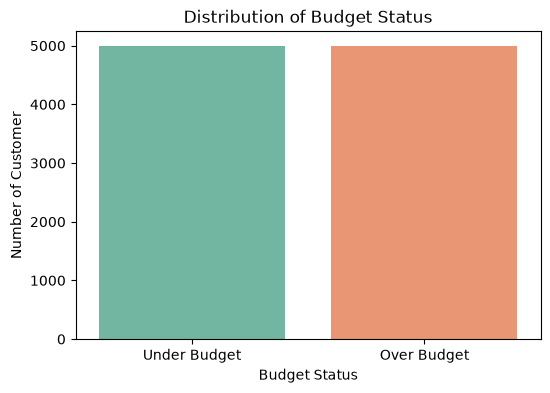

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Budget_Status', palette='Set2')

plt.title("Distribution of Budget Status")
plt.xlabel("Budget Status")
plt.ylabel("Number of Customer")
plt.show()

This graph shows the number of customers who are **Under Budget** and **Over Budget**.It helps us understand the class distribution of the target variable.

# Monthly Income Distribution

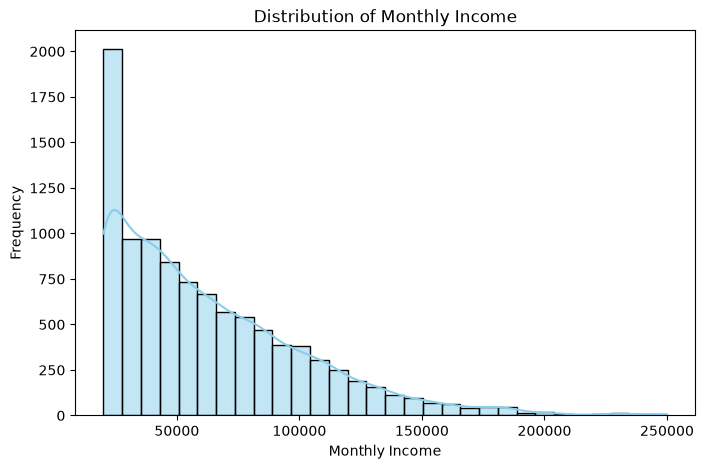

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(df['Monthly_Income'], bins=30, kde=True, color='skyblue')

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

This graph shows how monthly income is distributed amoung customers.It helps identify low, medium, and high-income groups.

# Income Vs Total Expenses

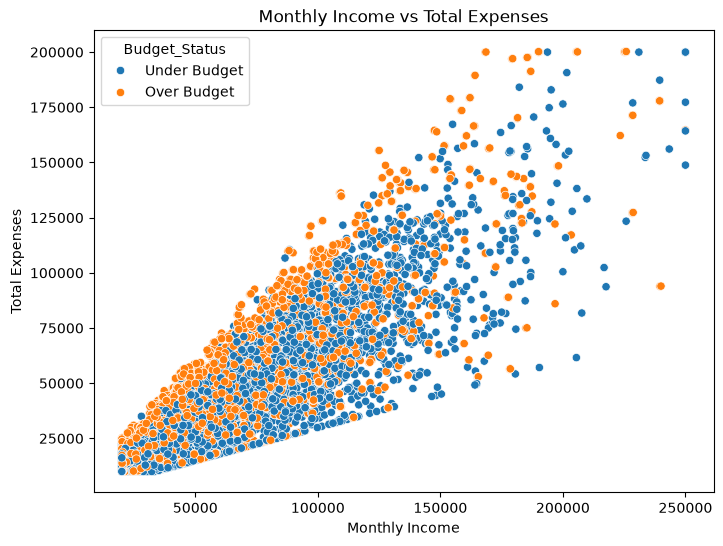

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Monthly_Income',
    y='Total_Expenses',
    hue='Budget_Status'

)

plt.title("Monthly Income vs Total Expenses")
plt.xlabel("Monthly Income")
plt.ylabel("Total Expenses")

plt.show()

Customers with higher income generally tend to have higher expenses.the graph also hightlights with customers remain under budget and which exceed their budget

# Correlation Heatmap

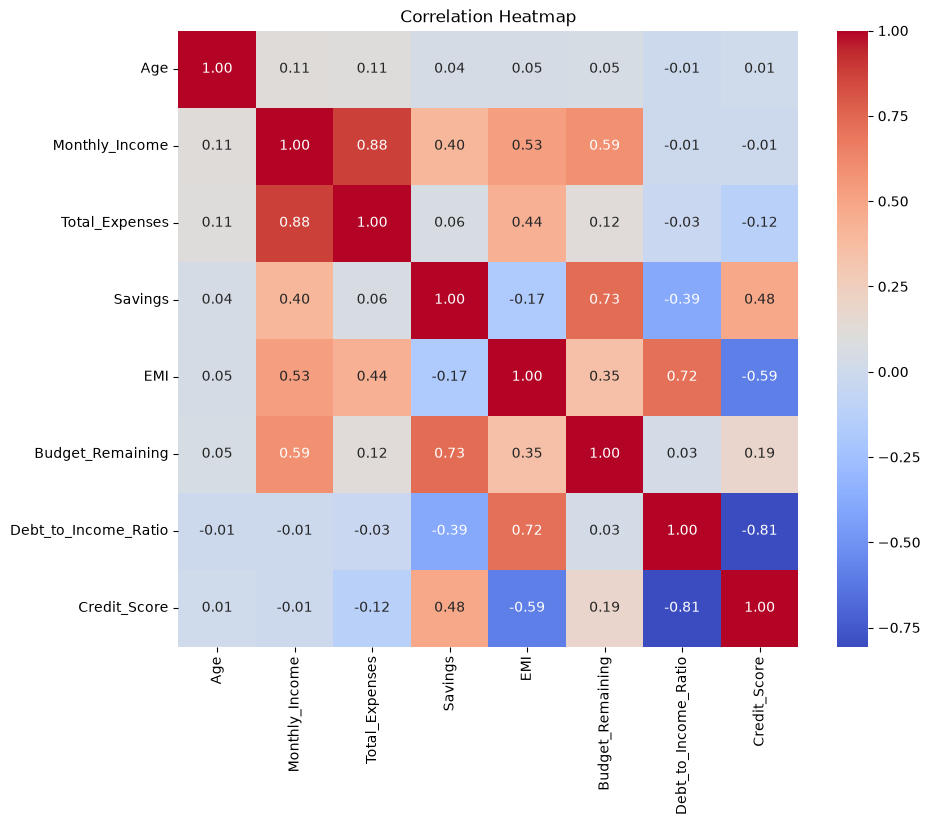

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

The Heatmap shows the correlation between numerical variables. strong positive or negative correlation  helps to identify important features for machine learning.

# Average Monthly Income by Occupation

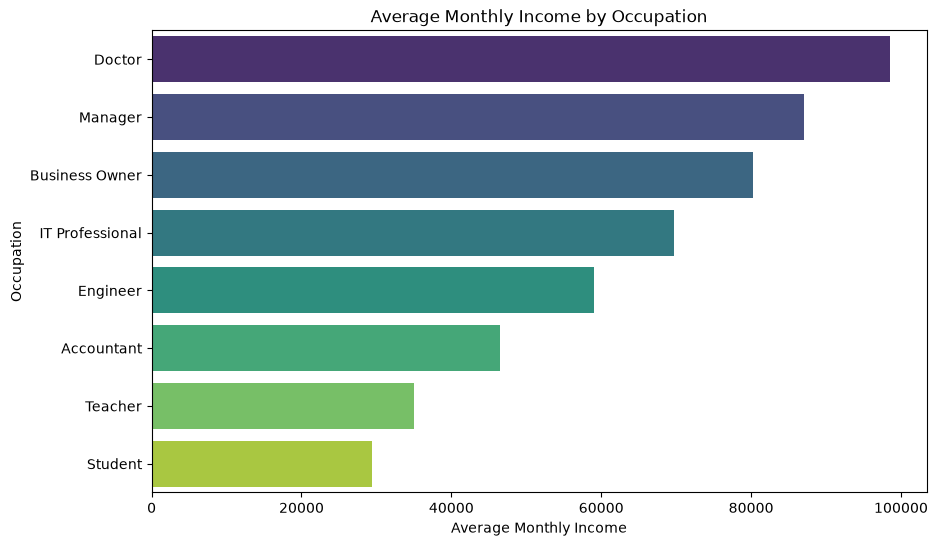

In [51]:
plt.figure(figsize=(10,6))

occupation_income = (
    df.groupby('Occupation')['Monthly_Income']
    .mean()
    .sort_values(ascending=False)

)

sns.barplot(
    x=occupation_income.values,
    y=occupation_income.index,
    palette='viridis'
)

plt.title("Average Monthly Income by Occupation")
plt.xlabel("Average Monthly Income")
plt.ylabel("Occupation")

plt.show()

This Graph compares the average monthly income across different occupataions.

In [52]:
df.drop("Customer_ID", axis=1, inplace=True)

df.head()

,Age,Gender,Marital_Status,Education,Occupation,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Financial_Goal,Credit_Score,Budget_Status
0,61,Male,Married,Bachelor's,Engineer,20000,15900,4600,0,4100,0.00,Retirement,776,Under Budget
1,30,Male,Married,Master's,Engineer,125300,118500,2600,5400,6800,0.04,Retirement,697,Under Budget
2,42,Male,Divorced,High School,IT Professional,65600,55200,8700,0,10400,0.00,Education,789,Under Budget
3,27,Male,Single,Bachelor's,IT Professional,33100,23500,300,9800,9600,0.30,Travel,675,Under Budget
4,18,Female,Single,Master's,Teacher,35000,26000,5200,4400,9000,0.13,Home Purchase,768,Under Budget


# Separate Features and Target

In [53]:
X = df.drop("Budget_Status", axis=1)

y = df["Budget_Status"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 13)
Target Shape: (10000,)


In [54]:
categorical_columns = X.select_dtypes(include="object").columns
categorical_columns

Index(['Gender', 'Marital_Status', 'Education', 'Occupation',
       'Financial_Goal'],
      dtype='object')

In [55]:
X = df.drop(columns=["Budget_Status"])
y = df["Budget_Status"]

# Apply Label Encoding

In [56]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "Gender",
    "Marital_Status",
    "Education",
    "Occupation",
    "Financial_Goal"
]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [57]:
X.head()

,Age,Gender,Marital_Status,Education,Occupation,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Financial_Goal,Credit_Score
0,61,1,1,0,3,20000,15900,4600,0,4100,0.00,4,776
1,30,1,1,2,3,125300,118500,2600,5400,6800,0.04,4,697
2,42,1,0,1,4,65600,55200,8700,0,10400,0.00,0,789
3,27,1,2,0,4,33100,23500,300,9800,9600,0.30,5,675
4,18,0,2,2,7,35000,26000,5200,4400,9000,0.13,2,768


In [58]:
pd.DataFrame({
    "Budget_Status": df["Budget_Status"],
    "Encoded": y
}).head()

,Budget_Status,Encoded
0,Under Budget,1
1,Under Budget,1
2,Under Budget,1
3,Under Budget,1
4,Under Budget,1


In [59]:
X.dtypes

Age                       int64
Gender                    int64
Marital_Status            int64
Education                 int64
Occupation                int64
Monthly_Income            int64
Total_Expenses            int64
Savings                   int64
EMI                       int64
Budget_Remaining          int64
Debt_to_Income_Ratio    float64
Financial_Goal            int64
Credit_Score              int64
dtype: object

# Feature Scaling

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed ✅")

Scaling Completed ✅


# Train-Test-Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 13)
(2000, 13)


In [63]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)


Training Features : (8000, 13)
Testing Features : (2000, 13)
Training Target : (8000,)
Testing Target : (2000,)


In [64]:
print("Training Target  Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Target Distribution:")
print(pd.Series(y_test).value_counts())

Training Target  Distribution:
0    4000
1    4000
Name: count, dtype: int64

Testing Target Distribution:
0    1000
1    1000
Name: count, dtype: int64


# Train The Logistic Regression Model

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [66]:
y_pred = model.predict(X_test)

Accuracy Score

In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7205


# Confusion Matrix

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[735 265]
 [294 706]]


# Confusion Matrix Visualization

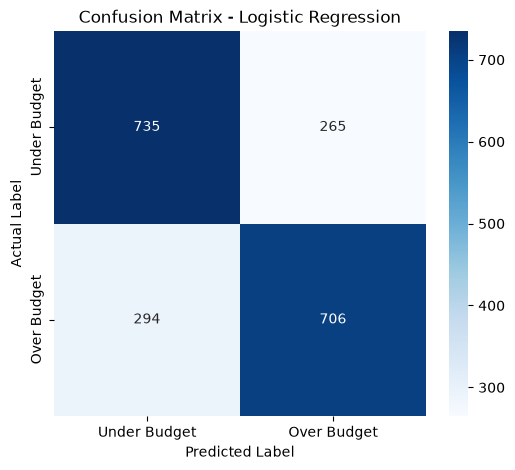

In [69]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Under Budget","Over Budget"],
    yticklabels=["Under Budget","Over Budget"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()



# Classification Report

In [70]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Under Budget","Over Budget"]
))

              precision    recall  f1-score   support

Under Budget       0.71      0.73      0.72      1000
 Over Budget       0.73      0.71      0.72      1000

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1 Score  : {f1:.2%}")

Precision : 72.71%
Recall    : 70.60%
F1 Score  : 71.64%


# Decision Tree Model

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [73]:
y_pred_dt = dt_model.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy : {accuracy_dt:.2%}")

Decision Tree Accuracy : 85.30%


In [75]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[906  94]
 [200 800]]


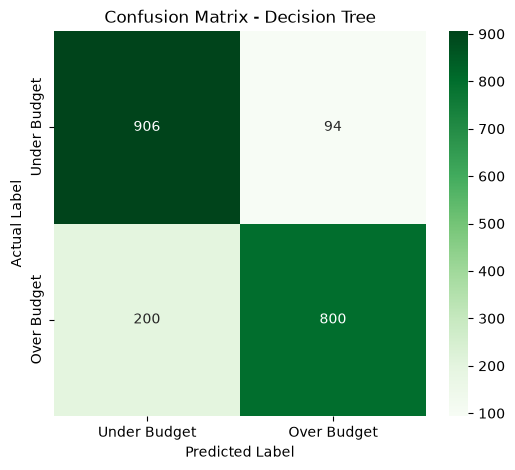

In [76]:

# Confusion Matrix Heatmap

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Under Budget", "Over Budget"],
    yticklabels=["Under Budget", "Over Budget"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [77]:

# Classification Report


from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Under Budget", "Over Budget"]
))

              precision    recall  f1-score   support

Under Budget       0.82      0.91      0.86      1000
 Over Budget       0.89      0.80      0.84      1000

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000



In [105]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Print results
print(f"Precision : {precision_dt:.2%}")
print(f"Recall    : {recall_dt:.2%}")
print(f"F1 Score  : {f1_dt:.2%}")

Precision : 89.49%
Recall    : 80.00%
F1 Score  : 84.48%


# Train the Random Forest Model

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [81]:
# Accuracy  Sore
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy : {accuracy_rf:.2%}")

Random Forest Accuracy : 91.35%


In [82]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[944  56]
 [117 883]]


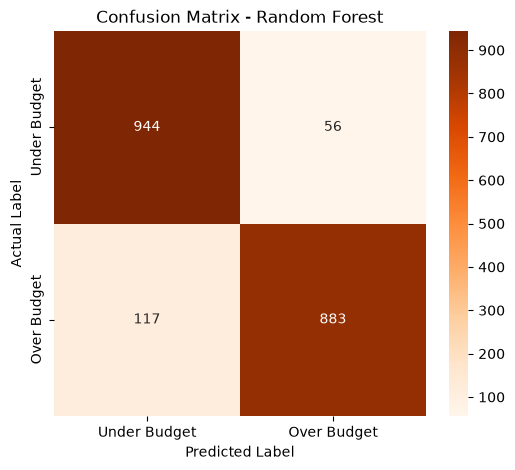

In [83]:

# Confusion Matrix Visualization
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Under Budget","Over Budget"],
    yticklabels=["Under Budget","Over Budget"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [ ]:

#  Classification Report


from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Under Budget","Over Budget"]
))

In [84]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Precision : {precision_rf:.2%}")
print(f"Recall    : {recall_rf:.2%}")
print(f"F1 Score  : {f1_rf:.2%}")

Precision : 94.04%
Recall    : 88.30%
F1 Score  : 91.08%


In [85]:
# Model Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7205,0.727085,0.706,0.716388
1,Decision Tree,0.8530,0.894855,0.800,0.844773
2,Random Forest,0.9135,0.940362,0.883,0.910779


In [86]:
comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7205,0.7271,0.706,0.7164
1,Decision Tree,0.8530,0.8949,0.800,0.8448
2,Random Forest,0.9135,0.9404,0.883,0.9108


In [87]:
comparison.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1 Score"],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.720500,0.727100,0.706000,0.716400
1,Decision Tree,0.853000,0.894900,0.800000,0.844800
2,Random Forest,0.913500,0.940400,0.883000,0.910800


# Accuracy Comparison Chart

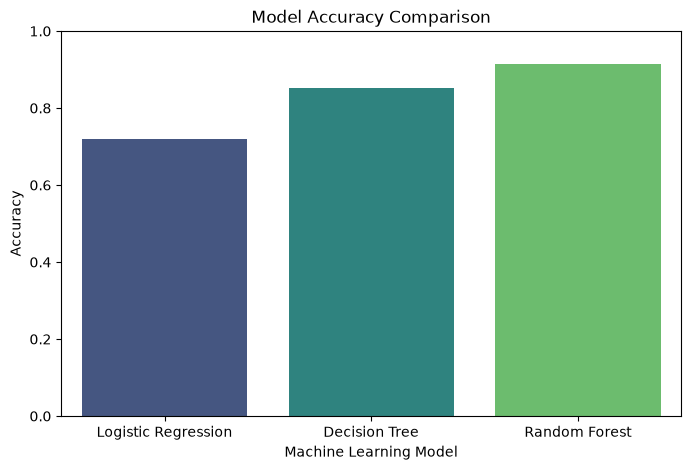

In [88]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

# Calculate Feature Importance

In [89]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,Age,0.070089
1,Gender,0.012612
2,Marital_Status,0.017920
3,Education,0.024281
4,Occupation,0.037554
5,Monthly_Income,0.091720
6,Total_Expenses,0.084617
7,Savings,0.135846
8,EMI,0.081035
9,Budget_Remaining,0.138627


# Plot Feature Importance

In [91]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

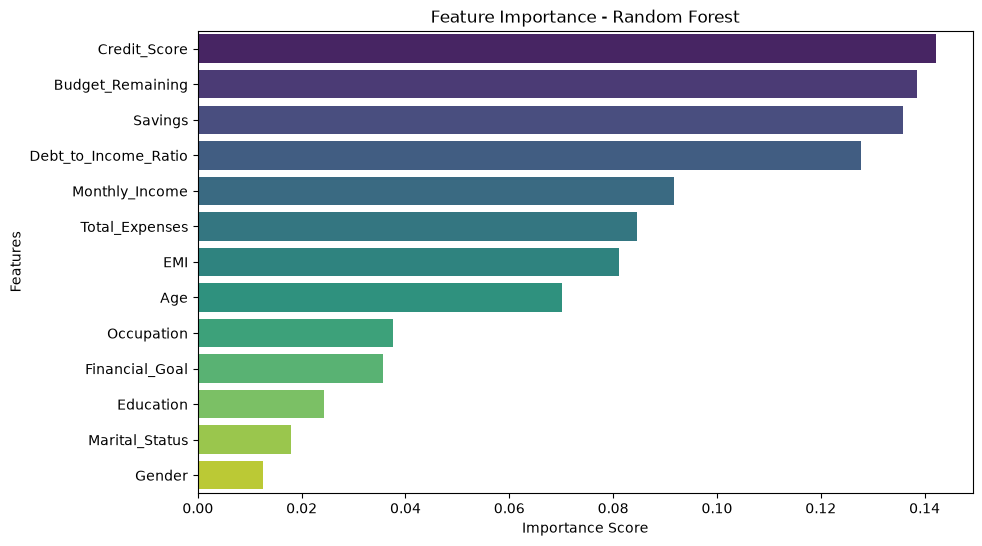

In [92]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [94]:
# Top 5 Features

top5 = feature_importance.head(5)

print("Top 5 Important Features:")
print(top5)

Top 5 Important Features:
                 Feature  Importance
12          Credit_Score    0.142185
9       Budget_Remaining    0.138627
7                Savings    0.135846
10  Debt_to_Income_Ratio    0.127816
5         Monthly_Income    0.091720


In [95]:
import joblib

joblib.dump(rf_model, "budget_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [96]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [97]:
import joblib

joblib.dump(encoders, "label_encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [98]:
df.head()

,Age,Gender,Marital_Status,Education,Occupation,Monthly_Income,Total_Expenses,Savings,EMI,Budget_Remaining,Debt_to_Income_Ratio,Financial_Goal,Credit_Score,Budget_Status
0,61,Male,Married,Bachelor's,Engineer,20000,15900,4600,0,4100,0.00,Retirement,776,Under Budget
1,30,Male,Married,Master's,Engineer,125300,118500,2600,5400,6800,0.04,Retirement,697,Under Budget
2,42,Male,Divorced,High School,IT Professional,65600,55200,8700,0,10400,0.00,Education,789,Under Budget
3,27,Male,Single,Bachelor's,IT Professional,33100,23500,300,9800,9600,0.30,Travel,675,Under Budget
4,18,Female,Single,Master's,Teacher,35000,26000,5200,4400,9000,0.13,Home Purchase,768,Under Budget


In [99]:
X = df.drop("Budget_Status", axis=1)
print(X.columns)

Index(['Age', 'Gender', 'Marital_Status', 'Education', 'Occupation',
       'Monthly_Income', 'Total_Expenses', 'Savings', 'EMI',
       'Budget_Remaining', 'Debt_to_Income_Ratio', 'Financial_Goal',
       'Credit_Score'],
      dtype='object')


In [101]:
print(df["Gender"].unique())

print(df["Marital_Status"].unique())

print(df["Education"].unique())

print(df["Occupation"].unique())

print(df["Financial_Goal"].unique())

['Male' 'Female']
['Married' 'Divorced' 'Single']
["Bachelor's" "Master's" 'High School' 'PhD']
['Engineer' 'IT Professional' 'Teacher' 'Business Owner' 'Accountant'
 'Student' 'Manager' 'Doctor']
['Retirement' 'Education' 'Travel' 'Home Purchase' 'Emergency Fund'
 'Investment']


In [102]:
print(df["Budget_Status"].unique())

['Under Budget' 'Over Budget']


In [103]:
import joblib

joblib.dump(encoders, "label_encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("Files Saved Successfully ✅")

Files Saved Successfully ✅


In [104]:
print(type(encoders["Gender"]))
print(encoders["Gender"].classes_)

<class 'sklearn.preprocessing._label.LabelEncoder'>
['Female' 'Male']
